In [1]:
import sys
import os

import xarray as xr
import rioxarray
import sys
sys.path.insert(1, '../Tools/')
import argparse 
import os
import sys
import xarray as xr
import mypythonlib
from mypythonlib import myfunctions 
import geopandas as gpd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import mapping
import warnings
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from matplotlib.ticker import MaxNLocator, FuncFormatter
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import shape, MultiPolygon, box
from affine import Affine
import rasterio
from shapely import wkt

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
def calculate_area(gdf):
    """Calculate area in square meters and square kilometers for a GeoDataFrame."""
    # Set the coordinate reference system (CRS) for the GeoDataFrame to WGS84
    gdf.crs = 'EPSG:4326'
    
    # Calculate the area in degrees (not used for final calculation, but keeping it here if needed for other purposes)
    #gdf['area_degrees'] = gdf.geometry.area
    
    # Define the target projection system (e.g., UTM Zone 18N)
    target_crs = 'EPSG:32618'
    
    # Reproject the GeoDataFrame to the target projection system
    gdf_projected = gdf.to_crs(target_crs)
    
    # Calculate the area in square meters
    print("     Calculating area in square meters...")
    gdf_projected['area_meters'] = gdf_projected.geometry.area
    
    # Assign the calculated area back to the original GeoDataFrame
    gdf['area_meters'] = gdf_projected['area_meters']
    # Convert square meters to square kilometers
    gdf['square_km'] = gdf['area_meters'] / 1e6
    # Print step information
    print("     Converting area from square meters to square kilometers...")
    
    # Return the GeoDataFrame with the new area columns
    return gdf

# Analysis of IDS / REFDM

In [25]:
# Define the path to your shapefile
refdm_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping.shp"

# Load the shapefile using geopandas
refdm_dataset = gpd.read_file(refdm_path)

# Optionally, display the CRS (Coordinate Reference System)
print("CRS:", refdm_dataset.crs)

CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [26]:
print(f"Size of refdm_dataset: {len(refdm_dataset)}")

# Dissolve the dataset by the USDA_IDX column
refdm_dissolved = refdm_dataset.dissolve(by='USDA_IDX')

print(f"Size of unique refdm_dataset events : {len(refdm_dissolved)}")

# Optionally, reset the index if needed
refdm_dissolved.reset_index(inplace=True)
refdm_dissolved.head()

Size of refdm_dataset: 41776
Size of unique refdm_dataset events : 16754


,USDA_IDX,geometry,S1_YEAR,S1_TILE,S1CD_IDX,DCA_ID,SURV_YEAR,REG_ID,DAM_TYPE,DAM_TYPE_C,DCA_CD,DA_CD_USDA,PCT_AFFECT,HOST,HOST_CODE,cluster_id,area_degre,area_meter,square_km
0,bark_beetle_2017_0,"MULTIPOLYGON (((-86.10050 32.13959, -86.10031 ...",2017,E093N027T3,0,bark_beetle,2017,8,Mortality,2,11003,1,No Data,None,-1,14245,0.000025,271290.660488,0.271291
1,bark_beetle_2017_1,"MULTIPOLYGON (((-86.02044 32.00776, -86.02006 ...",2017,E093N027T3,1,bark_beetle,2017,8,Mortality,2,11003,1,No Data,None,-1,14246,0.000005,52167.167717,0.052167
2,bark_beetle_2017_10,"MULTIPOLYGON (((-86.99148 32.66153, -86.99129 ...",2017,E090N027T3,10,bark_beetle,2017,8,Mortality,2,11003,1,No Data,None,-1,14253,0.000003,31410.503058,0.031411
3,bark_beetle_2017_100,"MULTIPOLYGON (((-86.13226 32.05395, -86.13226 ...",2017,E093N027T3,100,bark_beetle,2017,8,Mortality,2,11003,1,No Data,None,-1,14299,0.000005,58542.117835,0.058542
4,bark_beetle_2017_1000,"MULTIPOLYGON (((-88.87971 34.05735, -88.87971 ...",2017,E090N027T3,1000,bark_beetle,2017,8,Mortality,2,11003,1,No Data,None,-1,9940,0.000012,130033.316856,0.130033


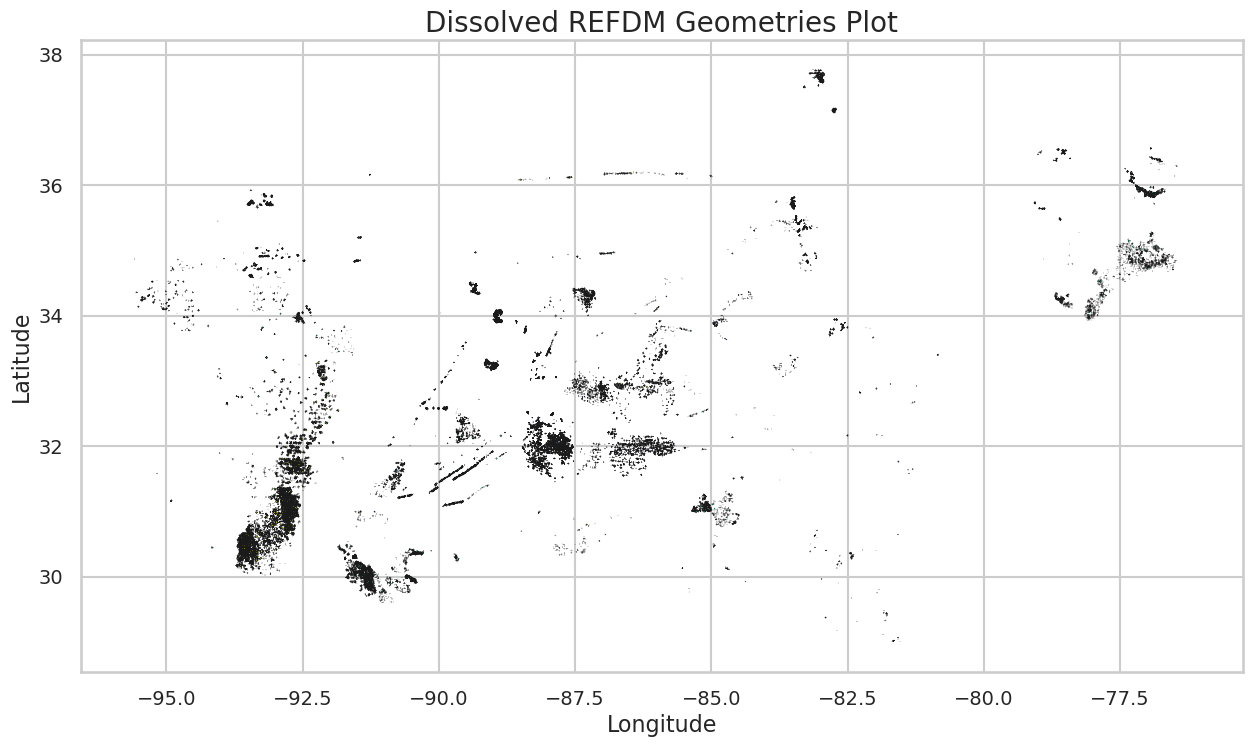

In [27]:
# Set up Seaborn's plotting aesthetics
sns.set(style="whitegrid", context="talk")

# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(15, 15))  # Adjust the figsize as needed

# Plot the GeoDataFrame with GeoPandas
refdm_dissolved.plot(ax=ax, edgecolor='k', linewidth=0.1, alpha=1, cmap='viridis')  # Adjust plot settings as needed

# Customize the plot
ax.set_title('Dissolved REFDM Geometries Plot', fontsize=20)
ax.set_xlabel('Longitude', fontsize=16)
ax.set_ylabel('Latitude', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True)

# Show the plot
plt.show()


In [30]:
print("Step 1: Loading CSV file...")
input_file = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.csv"
df = pd.read_csv(input_file)

# Step 2: Convert the WKT geometries to Shapely geometries
print("Step 2: Converting WKT geometries...")
df['geometry'] = df['geometry'].apply(wkt.loads)

# Step 3: Convert the DataFrame to a GeoDataFrame
print("Step 3: Converting DataFrame to GeoDataFrame...")
gdf = gpd.GeoDataFrame(df, geometry='geometry')
gdf_ids = gdf.rename(columns={'index_usda': 'USDA_IDX'})
print(f"Elements in the Dataframe: {len(gdf_ids)}")
gdf_ids.head(5)
gdf= gdf_ids

Step 1: Loading CSV file...
Step 2: Converting WKT geometries...
Step 3: Converting DataFrame to GeoDataFrame...
Elements in the Dataframe: 19227


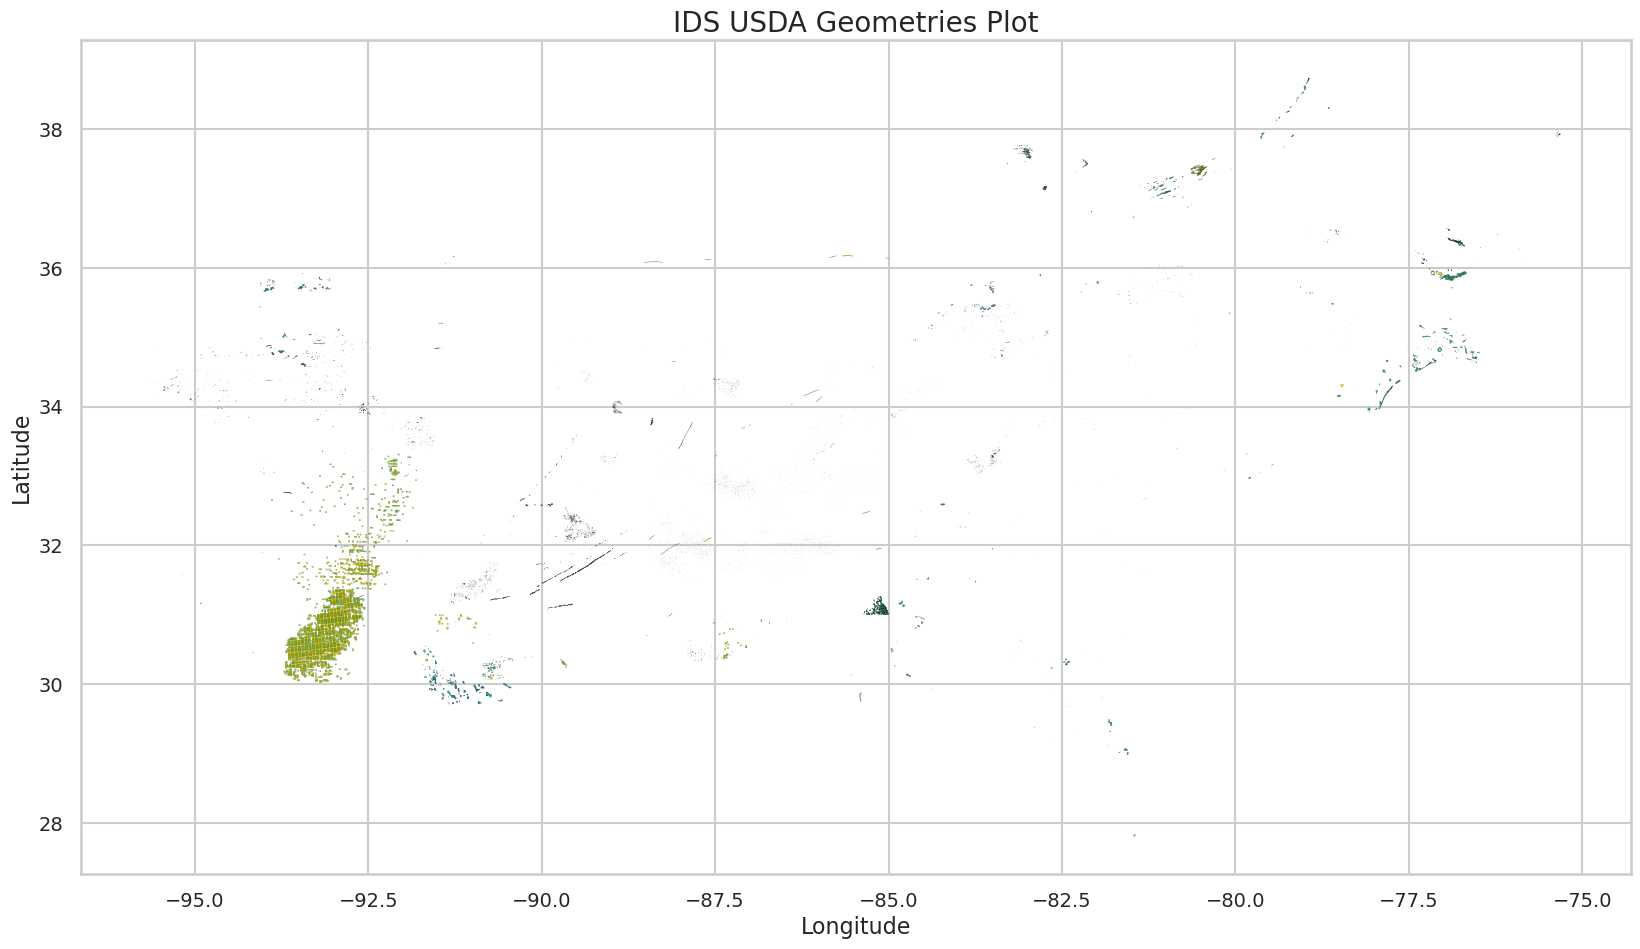

In [23]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up Seaborn's plotting aesthetics
sns.set(style="whitegrid", context="talk")

# Load your GeoDataFrame
# gdf = gpd.read_file("path_to_your_file.shp")  # Uncomment and adjust this line to load your file

# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(20, 20))  # Adjust the figsize as needed

# Plot the GeoDataFrame with GeoPandas
gdf_ids.plot(ax=ax, edgecolor='k', linewidth=0.1, alpha=1, cmap='viridis')  # Reduce edge line width and adjust alpha

# Customize the plot
ax.set_title('IDS USDA Geometries Plot', fontsize=20)
ax.set_xlabel('Longitude', fontsize=16)
ax.set_ylabel('Latitude', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True)

# Show the plot
plt.show()


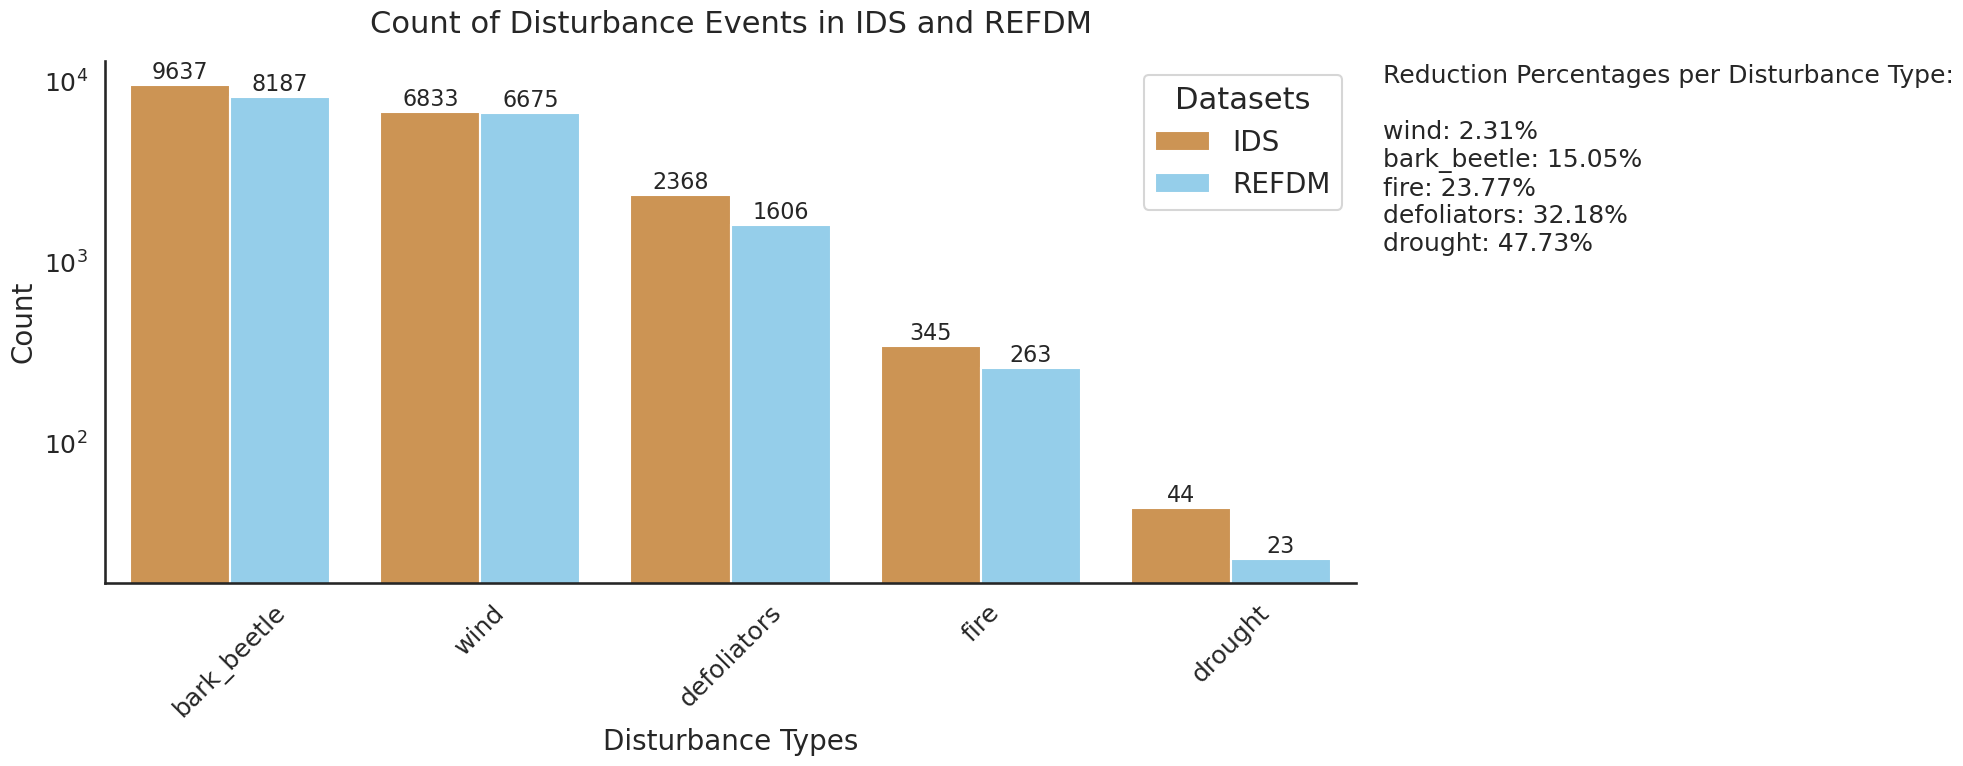

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by DCA_ID and count occurrences for both datasets
dca_counts_refdm = refdm_dissolved['DCA_ID'].value_counts()
dca_counts_ids = gdf['DCA_ID'].value_counts()

# Combine the counts into a single DataFrame
counts_df = pd.DataFrame({
    'IDS': dca_counts_ids,
    'REFDM': dca_counts_refdm
}).fillna(0)  # Fill NaN with 0 for counts that are missing in either dataset

# Reset index to turn DCA_ID into a column
counts_df.reset_index(inplace=True)
counts_df.rename(columns={'index': 'DCA_ID'}, inplace=True)

# Calculate reduction percentage
counts_df['Reduction (%)'] = 100 * (counts_df['IDS'] - counts_df['REFDM']) / counts_df['IDS']

# Sort the DataFrame by 'Reduction (%)' in ascending order
counts_df_sorted = counts_df.sort_values(by='Reduction (%)')

# Format the reduction percentages into a string for display
reduction_text = "Reduction Percentages per Disturbance Type:\n\n"
for index, row in counts_df_sorted.iterrows():
    reduction_text += f"{row['DCA_ID']}: {row['Reduction (%)']:.2f}%\n"

# Drop the 'Reduction (%)' column from counts_df if it exists
if 'Reduction (%)' in counts_df.columns:
    counts_df.drop(columns=['Reduction (%)'], inplace=True)

# Melt the DataFrame for easier plotting with Seaborn
counts_melted = counts_df.melt(id_vars='DCA_ID', var_name='Dataset', value_name='Count')


# Set the style and color palette
sns.set(style="white", context="talk")

# Define the custom color palette with bold shades of blue and orange
#palette = sns.color_palette(["#C5D86D", "#F96900"])  # Bold blue and bold orange
#palette = sns.color_palette(["#12A5A3", "#CA0266"])  # teal and rose 
#palette = sns.color_palette(["#BCB6FF", "#AF42AE"]) #Periwinkel and purpureus "#B3001B"]) 
palette = sns.color_palette(["#E09540", "#87D3F8"]) #Butterscotch and Pale azure
# Create the bar plot
plt.figure(figsize=(14, 8))
ax = sns.barplot(data=counts_melted, x='DCA_ID', y='Count', hue='Dataset', palette=palette)

# Add numbers over the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=16)

# Customize the plot
plt.xlabel('Disturbance Types', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.title('Count of Disturbance Events in IDS and REFDM', fontsize=22, pad=20)  # Adjust title position
plt.xticks(rotation=45, fontsize=18)
plt.yticks(fontsize=18)
plt.yscale('log')  # Set y-axis to log scale
plt.legend(title='Datasets', title_fontsize=22, fontsize=20)
plt.gca().spines['top'].set_visible(False)  # Hide top spine
plt.gca().spines['right'].set_visible(False)  # Hide right spine
plt.gca().yaxis.grid(False)  # Remove y-axis gridlines
plt.tight_layout()

# Add reduction percentages as a text box
plt.gcf().text(1, 0.63, reduction_text, fontsize=18, bbox=dict(facecolor='white', alpha=0.5))

plt.show()

In [31]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# Calculate centroids for each polygon
gdf['centroid'] = gdf.geometry.centroid
refdm_dissolved['centroid'] = refdm_dissolved.geometry.centroid

# Initialize lists to hold the results
usda_idx_list = []
centroid_shift_list = []
size_difference_list = []

# Iterate through unique USDA_IDX values
unique_usda_idx = gdf['USDA_IDX'].unique()

for usda_idx in unique_usda_idx:
    # Get the corresponding rows in both GeoDataFrames
    gdf_row = gdf[gdf['USDA_IDX'] == usda_idx]
    refdm_row = refdm_dissolved[refdm_dissolved['USDA_IDX'] == usda_idx]
    
    if not gdf_row.empty and not refdm_row.empty:
        # Calculate the centroid shift
        centroid_shift = gdf_row.iloc[0]['centroid'].distance(refdm_row.iloc[0]['centroid'])
        
        # Calculate the size difference
        size_difference = gdf_row.iloc[0]['geometry'].area - refdm_row.iloc[0]['geometry'].area
        
        # Append the results to the lists
        usda_idx_list.append(usda_idx)
        centroid_shift_list.append(centroid_shift)
        size_difference_list.append(size_difference)

# Create a DataFrame from the results
results_df = pd.DataFrame({
    'USDA_IDX': usda_idx_list,
    'centroid_shift': centroid_shift_list,
    'size_difference': size_difference_list
})

# Merge with original gdf to get geometry
result_gdf = gdf.merge(results_df, on='USDA_IDX')

# Save the results in a new GeoDataFrame
result_gdf = gpd.GeoDataFrame(result_gdf, geometry='geometry', crs=gdf.crs)

# Check for negative values in the 'size_difference' column
negative_values_exist = (result_gdf['size_difference'] < 0).any()

if negative_values_exist:
    print("There are negative values in the 'size_difference' column.")
else:
    print("There are no negative values in the 'size_difference' column.")

# Check for negative values in the 'size_difference' column
negative_values_exist_centroid_shift = (result_gdf['centroid_shift'] < 0).any()

if negative_values_exist_centroid_shift:
    print("There are negative values in the 'centroid_shift' column.")
else:
    print("There are no negative values in the 'centroid_shift' column.")


/tmp/ipykernel_1466708/822557236.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  refdm_dissolved['centroid'] = refdm_dissolved.geometry.centroid


There are negative values in the 'size_difference' column.
There are no negative values in the 'centroid_shift' column.


/tmp/ipykernel_1466708/1146270963.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=result_gdf, x='DCA_ID', y='centroid_shift', palette=custom_palette)
/tmp/ipykernel_1466708/1146270963.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=result_gdf, x='DCA_ID', y='size_difference', palette=custom_palette)


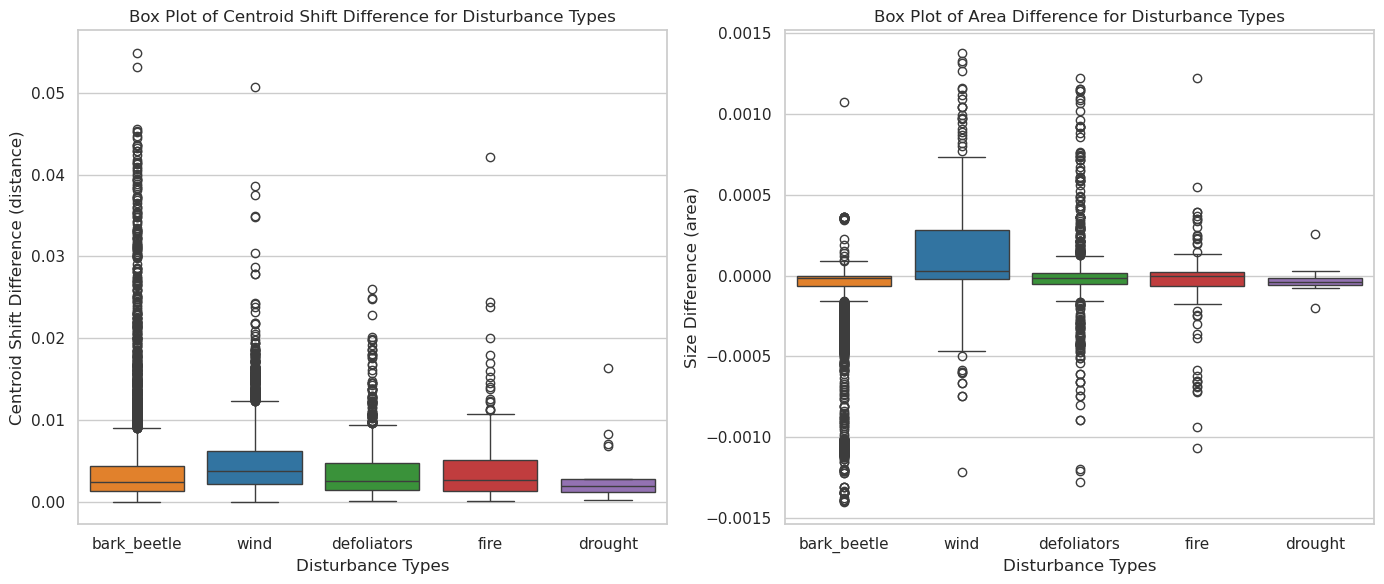

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define specific colors for each disturbance type
custom_colors = {
    'wind': '#1f77b4',      # tab:blue
    'fire': '#d62728',      # tab:red
    'defoliators': '#2ca02c',  # tab:green
    'drought': '#9467bd',   # tab:purple
    'bark_beetle': '#ff7f0e'  # tab:orange
}

# Get the default colors from 'tab10' palette for the rest of the disturbance types
default_palette = sns.color_palette('tab10', n_colors=10)
default_colors = [color for color in default_palette if color not in custom_colors.values()]

# Combine the custom colors with the default colors
custom_palette = [custom_colors.get(label, default_colors.pop(0)) for label in result_gdf['DCA_ID'].unique()]


# Set Seaborn style
sns.set(style="whitegrid")

# Create box plots for centroid shift difference
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=result_gdf, x='DCA_ID', y='centroid_shift', palette=custom_palette)
plt.title('Box Plot of Centroid Shift Difference for Disturbance Types')
plt.xlabel('Disturbance Types')
plt.ylabel('Centroid Shift Difference (distance)')

# Create box plots for area difference
plt.subplot(1, 2, 2)
sns.boxplot(data=result_gdf, x='DCA_ID', y='size_difference', palette=custom_palette)
plt.title('Box Plot of Area Difference for Disturbance Types')
plt.xlabel('Disturbance Types')
plt.ylabel('Size Difference (area)')

plt.tight_layout()
plt.show()


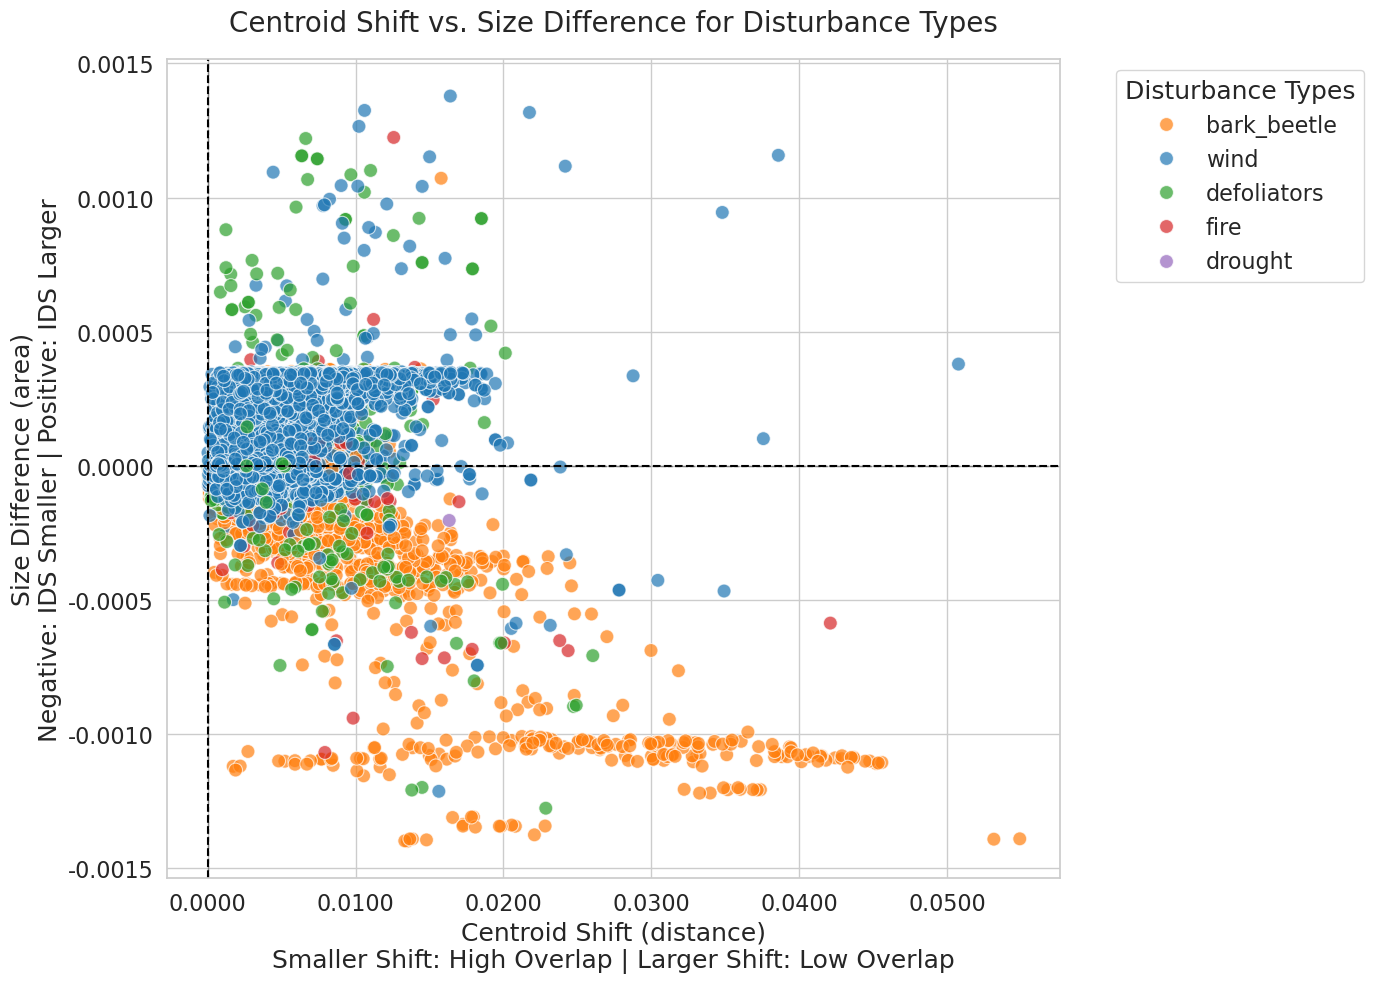

In [33]:
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter  # Import the necessary module

# Define specific colors for each disturbance type
custom_colors = {
    'wind': '#1f77b4',      # tab:blue
    'fire': '#d62728',      # tab:red
    'defoliators': '#2ca02c',  # tab:green
    'drought': '#9467bd',   # tab:purple
    'bark_beetle': '#ff7f0e'  # tab:orange
}

# Get the default colors from 'tab10' palette for the rest of the disturbance types
default_palette = sns.color_palette('tab10', n_colors=10)
default_colors = [color for color in default_palette if color not in custom_colors.values()]

# Combine the custom colors with the default colors
custom_palette = [custom_colors.get(label, default_colors.pop(0)) for label in result_gdf['DCA_ID'].unique()]

# Set Seaborn style
sns.set(style="whitegrid")

# Plot the results with the custom palette
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=result_gdf,
    x='centroid_shift',
    y='size_difference',
    hue='DCA_ID',
    palette=custom_palette,
    s=100,
    edgecolor='w',
    alpha=0.7
)

# Customize the plot
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel('Centroid Shift (distance)\nSmaller Shift: High Overlap | Larger Shift: Low Overlap', fontsize=18)
plt.ylabel('Size Difference (area)\nNegative: IDS Smaller | Positive: IDS Larger', fontsize=18)
plt.title('Centroid Shift vs. Size Difference for Disturbance Types', fontsize=20, pad=20)
legend = plt.legend(title='Disturbance Types', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)
legend.set_title('Disturbance Types', prop={'size': 18})  # Set legend title size

# # Set log scale for both axes
# plt.xscale('log')
# plt.yscale('log')

# Set decimal tick labels
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.4f'))
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.4f'))

# Increase tick label size
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Show quadrant lines
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.show()


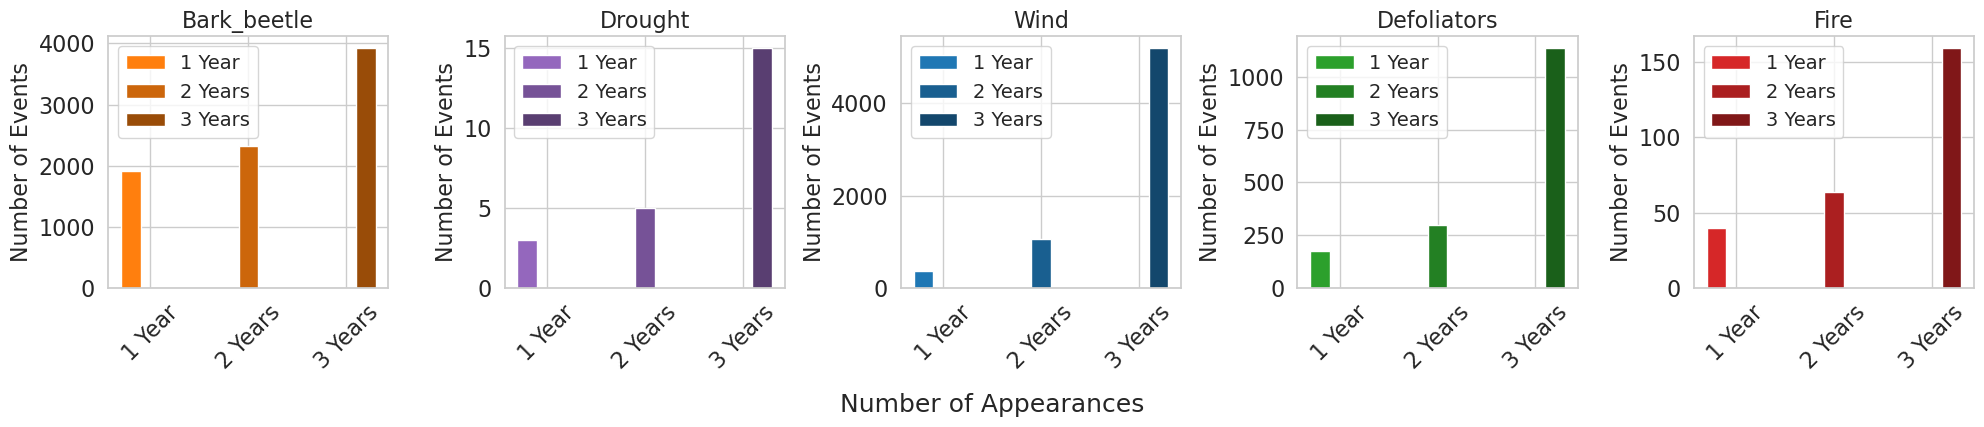

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Define specific colors for each disturbance type
custom_colors = {
    'wind': '#1f77b4',      # tab:blue
    'fire': '#d62728',      # tab:red
    'defoliators': '#2ca02c',  # tab:green
    'drought': '#9467bd',   # tab:purple
    'bark_beetle': '#ff7f0e'  # tab:orange
}

# Get the default colors from 'tab10' palette for the rest of the disturbance types
default_palette = sns.color_palette('tab10', n_colors=10)
default_colors = [color for color in default_palette if color not in custom_colors.values()]

dca_ids = refdm_dataset['DCA_ID'].unique()

# Function to create shades of a color
def create_shades(color, n):
    base_color = np.array(mcolors.to_rgb(color))
    return [mcolors.to_hex(base_color * (1 - 0.2 * i)) for i in range(n)]

# Define the width of each bar
bar_width = 0.2

# Extract unique DCA_IDs from the dataset
dca_ids = refdm_dataset['DCA_ID'].unique()

# Create subplots for each DCA_ID
fig, axs = plt.subplots(1, len(dca_ids), figsize=(20, 4), sharex=True)

# Iterate over each DCA_ID
for i, dca_id in enumerate(dca_ids):
    # Filter refdm_dataset for the current DCA_ID
    dca_data = refdm_dataset[refdm_dataset['DCA_ID'] == dca_id]
    
    # Group the data by USDA_IDX and count occurrences
    usda_idx_counts = dca_data.groupby('USDA_IDX').size()
    
    # Count occurrences of USDA_IDX with 1, 2, or 3 instances
    usda_idx_1_instance = sum(usda_idx_counts == 1)
    usda_idx_2_instances = sum(usda_idx_counts == 2)
    usda_idx_3_instances = sum(usda_idx_counts == 3)
    
    # Calculate the x positions for the bars
    x = np.arange(3)
    
    # Get the color shades for the current DCA_ID
    shades = create_shades(custom_colors.get(dca_id, '#000000'), 3)
    
    # Plot the bars for each year
    axs[i].bar(x - bar_width, [usda_idx_1_instance, 0, 0], width=bar_width, label='1 Year', color=shades[0])
    axs[i].bar(x, [0, usda_idx_2_instances, 0], width=bar_width, label='2 Years', color=shades[1])
    axs[i].bar(x + bar_width, [0, 0, usda_idx_3_instances], width=bar_width, label='3 Years', color=shades[2])
    
    # Set plot title and y-axis label with larger font sizes
    axs[i].set_title(f'{dca_id.capitalize()}', fontsize=16)
    axs[i].set_ylabel('Number of Events', fontsize=16)
    axs[i].set_xticks(x)
    axs[i].tick_params(axis='x', labelsize=16, rotation=45)
    axs[i].tick_params(axis='y', labelsize=16)
    axs[i].legend(fontsize=14)
    
    # Set x-tick labels separately to avoid FixedFormatter warning
    axs[i].set_xticklabels(['1 Year', '2 Years', '3 Years'])

# Set common x-axis label with larger font size
fig.text(0.5, -0.05, 'Number of Appearances', ha='center', fontsize=18)
fig.tight_layout()

# Show the plot
plt.show()


/tmp/ipykernel_1466708/2779377851.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1466708/2779377851.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1466708/2779377851.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1466708/2779377851.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1466708/2779377851.py:45: Fut

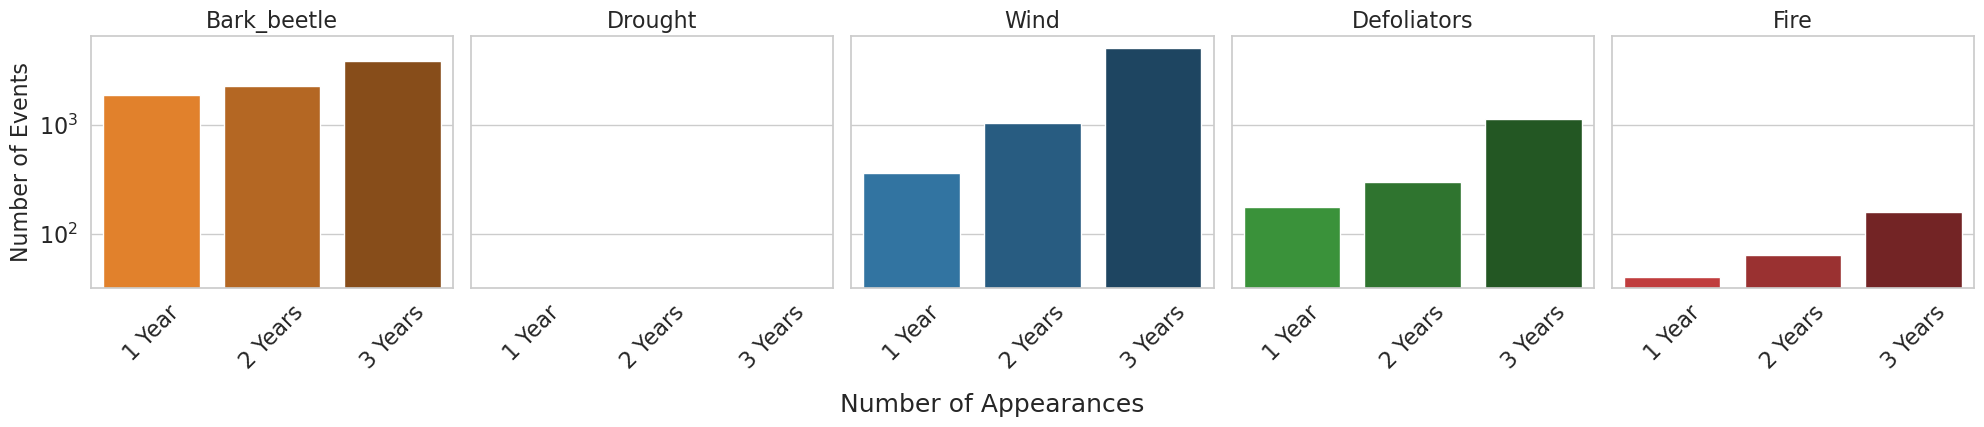

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors

# Define specific colors for each disturbance type
custom_colors = {
    'wind': '#1f77b4',      # tab:blue
    'fire': '#d62728',      # tab:red
    'defoliators': '#2ca02c',  # tab:green
    'drought': '#9467bd',   # tab:purple
    'bark_beetle': '#ff7f0e'  # tab:orange
}

# Function to create shades of a color
def create_shades(color, n):
    base_color = np.array(mcolors.to_rgb(color))
    return [mcolors.to_hex(base_color * (1 - 0.2 * i)) for i in range(n)]

# Extract unique DCA_IDs from the dataset
dca_ids = refdm_dataset['DCA_ID'].unique()

# Create a long format dataframe for seaborn
plot_data = []
for dca_id in dca_ids:
    dca_data = refdm_dataset[refdm_dataset['DCA_ID'] == dca_id]
    usda_idx_counts = dca_data.groupby('USDA_IDX').size()
    usda_idx_1_instance = sum(usda_idx_counts == 1)
    usda_idx_2_instances = sum(usda_idx_counts == 2)
    usda_idx_3_instances = sum(usda_idx_counts == 3)
    
    plot_data.append({'DCA_ID': dca_id, 'Years': '1 Year', 'Count': usda_idx_1_instance})
    plot_data.append({'DCA_ID': dca_id, 'Years': '2 Years', 'Count': usda_idx_2_instances})
    plot_data.append({'DCA_ID': dca_id, 'Years': '3 Years', 'Count': usda_idx_3_instances})

plot_df = pd.DataFrame(plot_data)

# Create subplots for each DCA_ID
fig, axs = plt.subplots(1, len(dca_ids), figsize=(20, 4), sharex=True, sharey=True)

# Iterate over each DCA_ID to create individual bar plots
for i, dca_id in enumerate(dca_ids):
    ax = axs[i]
    sns.barplot(
        data=plot_df[plot_df['DCA_ID'] == dca_id],
        x='Years', y='Count', ax=ax,
        palette=create_shades(custom_colors.get(dca_id, '#000000'), 3)
    )
    ax.set_yscale('log')
    ax.set_title(f'{dca_id.capitalize()}', fontsize=16)
    ax.set_xlabel('')
    ax.set_ylabel('Number of Events' if i == 0 else '', fontsize=16)
    ax.tick_params(axis='x', labelsize=16, rotation=45)
    ax.tick_params(axis='y', labelsize=16)

# Set common x-axis label with larger font size
fig.text(0.5, -0.05, 'Number of Appearances', ha='center', fontsize=18)
fig.tight_layout()

# Show the plot
plt.show()

# Merging of the years if there is a big enough overlapp

In [17]:
# Define the path to your shapefile
refdm_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping.shp"

# Load the shapefile using geopandas
refdm_dataset = gpd.read_file(refdm_path)

# Optionally, display the CRS (Coordinate Reference System)
print("CRS:", refdm_dataset.crs)
print("Amount of Events in the Radar-Enhanced-Forest-Disturbance-Mapping Dataset:", len(refdm_dataset))

refdm_dataset.head()

CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
Amount of Events in the Radar-Enhanced-Forest-Disturbance-Mapping Dataset: 41776


,USDA_IDX,S1_YEAR,S1_TILE,S1CD_IDX,DCA_ID,SURV_YEAR,REG_ID,DAM_TYPE,DAM_TYPE_C,DCA_CD,DA_CD_USDA,PCT_AFFECT,HOST,HOST_CODE,cluster_id,area_degre,area_meter,square_km,geometry
0,bark_beetle_2019_12801,2020,E084N024T3,12801,bark_beetle,2019,8,Mortality,2,11030,1,Light (4-10%),None,None,12360,0.000026,295662.269883,0.295662,"MULTIPOLYGON (((-94.92155 31.15303, -94.92078 ..."
1,bark_beetle_2019_12802,2020,E084N024T3,12802,bark_beetle,2019,8,Mortality,2,11030,1,Light (4-10%),None,None,12360,0.000009,102406.849951,0.102407,"MULTIPOLYGON (((-94.92386 31.15708, -94.92367 ..."
2,bark_beetle_2019_12803,2020,E084N024T3,12803,bark_beetle,2019,8,Mortality,2,11030,1,Light (4-10%),None,None,12360,0.000021,238655.338758,0.238655,"MULTIPOLYGON (((-94.91769 31.15149, -94.91750 ..."
3,bark_beetle_2019_12804,2020,E084N024T3,12804,bark_beetle,2019,8,Mortality,2,11030,1,Light (4-10%),None,None,12360,0.000018,207787.019607,0.207787,"MULTIPOLYGON (((-94.91558 31.15554, -94.91558 ..."
4,bark_beetle_2019_12805,2020,E084N024T3,12805,bark_beetle,2019,8,Mortality,2,11030,1,Very Light (1-3%),None,None,18275,0.000044,510175.284005,0.510175,"MULTIPOLYGON (((-94.90383 31.16151, -94.90325 ..."


In [178]:
import geopandas as gpd
import pandas as pd
from shapely.ops import unary_union

def calculate_geometry_overlap_score(dataset):
    """
    Calculate overlap scores and merge geometries with more than 70% overlap,
    storing their S1_YEAR values in a list.

    Parameters:
    dataset (GeoDataFrame): The input dataset with 'USDA_IDX' and 'geometry' columns.

    Returns:
    GeoDataFrame: A GeoDataFrame with merged geometries and their S1_YEAR values.
    """
    # Lists to hold merged and singular geometries
    merged_data = []
    singular_data = []

    # Iterate over unique USDA_IDX values
    for usda_idx in dataset['USDA_IDX'].unique():
        group = dataset[dataset['USDA_IDX'] == usda_idx]
        if len(group) == 1:
            singular_data.append(group)  # Add single entry groups to singular_data
        else:
            merged_geom = unary_union(group.geometry)  # Merge geometries
            s1_years = group['S1_YEAR'].tolist()  # List of S1_YEARs
            dca_id = group['DCA_ID'].tolist()  # List of DCA_IDs
            best_year = group.loc[group.geometry.area.idxmax()]['S1_YEAR']  # Best year by largest area

            # Append merged data
            merged_data.append({
                'USDA_IDX': usda_idx,
                'geometry': merged_geom,
                'S1_YEARs': s1_years,
                'best_year': best_year,
                'DCA_ID': dca_id
            })

    # Convert lists to GeoDataFrames
    merged_gdf = gpd.GeoDataFrame(merged_data)
    unmerged_gdf = pd.concat(singular_data, ignore_index=True) if singular_data else gpd.GeoDataFrame(columns=dataset.columns, crs=dataset.crs)

    # Concatenate GeoDataFrames
    concatenated_gdf = pd.concat([unmerged_gdf, merged_gdf], ignore_index=True)

    # Ensure CRS consistency
    concatenated_gdf = gpd.GeoDataFrame(concatenated_gdf, crs=merged_gdf.crs)

    # Keep specific columns and merge year columns
    columns_to_keep = ['USDA_IDX', 'geometry', 'S1_YEARs', 'best_year', 'S1_YEAR']
    concatenated_gdf = concatenated_gdf[columns_to_keep]
    concatenated_gdf['year_refdm'] = concatenated_gdf['best_year'].combine_first(concatenated_gdf['S1_YEAR'])

    # Drop the original year columns and return the final GeoDataFrame
    return concatenated_gdf.drop(columns=['best_year', 'S1_YEAR'])


In [182]:
import geopandas as gpd
import pandas as pd
from shapely.ops import unary_union

def calculate_dissolved_geometries_year(dataset):
    """
    Merge geometries and storetheir S1_YEAR values in a list.

    Parameters:
    dataset (GeoDataFrame): The input dataset with 'USDA_IDX' and 'geometry' columns.

    Returns:
    GeoDataFrame: A GeoDataFrame with merged geometries and their S1_YEAR values.
    """
    # Lists to hold merged and singular geometries
    merged_data = []
    singular_data = []

    # Iterate over unique USDA_IDX values
    for usda_idx in dataset['USDA_IDX'].unique():
        group = dataset[dataset['USDA_IDX'] == usda_idx]
        if len(group) == 1:
            singular_data.append(group)  # Add single entry groups to singular_data
        else:
            merged_geom = unary_union(group.geometry)  # Merge geometries
            s1_years = group['S1_YEAR'].tolist()  # List of S1_YEARs
            dca_id = group['DCA_ID'].tolist()  # List of DCA_IDs
            best_year = group.loc[group.geometry.area.idxmax()]['S1_YEAR']  # Best year by largest area

            # Append merged data
            merged_data.append({
                'USDA_IDX': usda_idx,
                'geometry': merged_geom,
                'S1_YEARs': s1_years,
                'best_year': best_year,
                'DCA_ID': dca_id
            })

    # Convert lists to GeoDataFrames
    merged_gdf = gpd.GeoDataFrame(merged_data)
    unmerged_gdf = pd.concat(singular_data, ignore_index=True) if singular_data else gpd.GeoDataFrame(columns=dataset.columns, crs=dataset.crs)

    # Concatenate GeoDataFrames
    concatenated_gdf = pd.concat([unmerged_gdf, merged_gdf], ignore_index=True)

    # Ensure CRS consistency
    concatenated_gdf = gpd.GeoDataFrame(concatenated_gdf, crs=merged_gdf.crs)

    # Keep specific columns and merge year columns
    columns_to_keep = ['USDA_IDX', 'geometry', 'S1_YEARs', 'best_year', 'S1_YEAR']
    concatenated_gdf = concatenated_gdf[columns_to_keep]
    concatenated_gdf['year_refdm'] = concatenated_gdf['best_year'].combine_first(concatenated_gdf['S1_YEAR'])

    # Drop the original year columns and return the final GeoDataFrame
    return concatenated_gdf.drop(columns=['best_year', 'S1_YEAR'])


In [181]:
dissolved_geometries_year = calculate_dissolved_geometries_year(refdm_dataset)
print(f"Events: {len(dissolved_geometries_year)}")
dissolved_geometries_year

NameError: name 'calculate_dissolved_geometries_year' is not defined

In [179]:
merged_gdf = calculate_geometry_overlap_score(refdm_dataset)
print(f"Events: {len(merged_gdf)}")
merged_gdf

/tmp/ipykernel_627997/4184389039.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  best_row = group.loc[group.geometry.area.idxmax()]
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/geopandas/array.py:1486: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  warnings.warn(


Events: 16754


,USDA_IDX,geometry,S1_YEARs,year_refdm
0,bark_beetle_2019_12802,"MULTIPOLYGON (((-94.92386 31.15708, -94.92367 ...",NaN,2020
1,bark_beetle_2019_12804,"MULTIPOLYGON (((-94.91558 31.15554, -94.91558 ...",NaN,2020
2,wind_2020_13102,"POLYGON ((-93.22208 30.86314, -93.22189 30.863...",NaN,2020
3,wind_2020_13110,"POLYGON ((-93.20648 30.89493, -93.20629 30.894...",NaN,2020
4,wind_2020_13139,"MULTIPOLYGON (((-93.19242 30.89204, -93.19281 ...",NaN,2020
...,...,...,...,...
16749,bark_beetle_2018_9846,"MULTIPOLYGON (((-89.64521 32.13072, -89.64521 ...","[2017, 2018]",2018
16750,bark_beetle_2018_9995,"MULTIPOLYGON (((-89.58923 32.10264, -89.58942 ...","[2017, 2018]",2017
16751,bark_beetle_2018_9996,"MULTIPOLYGON (((-89.63031 32.08430, -89.63012 ...","[2017, 2018]",2017
16752,bark_beetle_2017_2982,"MULTIPOLYGON (((-84.89068 30.61123, -84.89068 ...","[2017, 2018]",2018


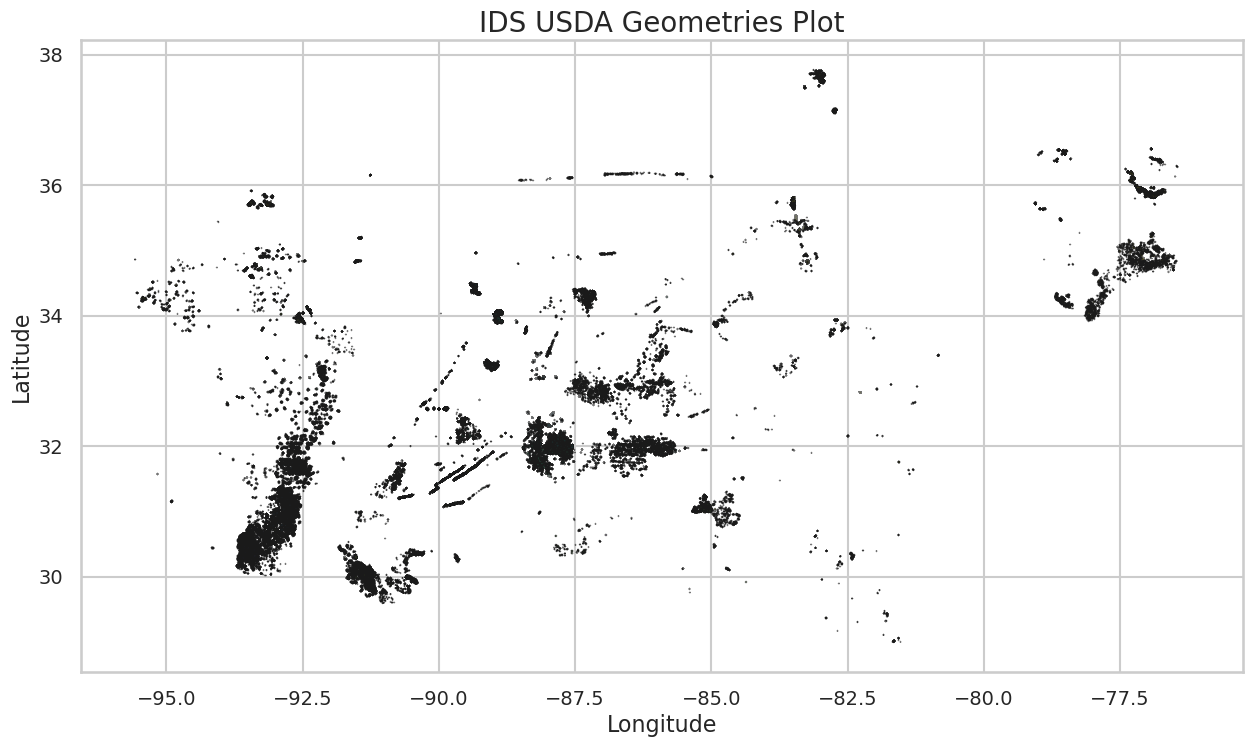

In [180]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up Seaborn's plotting aesthetics
sns.set(style="whitegrid", context="talk")

# Load your GeoDataFrame
# gdf = gpd.read_file("path_to_your_file.shp")  # Uncomment and adjust this line to load your file

# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(15, 15))  # Adjust the figsize as needed

# Plot the GeoDataFrame with GeoPandas
merged_gdf.plot(ax=ax, edgecolor='k', linewidth=1, alpha=0.6, cmap='viridis')  # Adjust plot settings as needed

# Customize the plot
ax.set_title('IDS USDA Geometries Plot', fontsize=20)
ax.set_xlabel('Longitude', fontsize=16)
ax.set_ylabel('Latitude', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True)

# Show the plot
plt.show()
